In [2]:
import os
OUTPUT_DIR = os.path.join(os.path.dirname(os.getcwd()), "outputs") if "notebooks" in os.getcwd() else "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ─────────────────────────────────────────────────────────────
# DEPENDENCIAS Y CARGA DESDE MONGODB ATLAS
# ─────────────────────────────────────────────────────────────
import os, re, certifi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pymongo import MongoClient
from dotenv import load_dotenv  # Agregado para leer el archivo .env
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# Cargar variables del archivo .env físico
load_dotenv() 

# Leer la URI de forma segura sin dejar contraseñas quemadas en el código
MONGO_URI = os.getenv('MONGO_URI')

if not MONGO_URI:
    raise ValueError("Error: No se encontró MONGO_URI. Revisa que el archivo .env exista y esté bien configurado.")

client = MongoClient(MONGO_URI, tlsCAFile=certifi.where())
db     = client['Proyecto_Bigdata']
datos  = list(db['processed_data'].find({}, {'_id': 0}))
client.close()

df = pd.DataFrame(datos)
print(f'Registros cargados: {len(df):,}')
print(f'Columnas: {df.columns.tolist()}')

# ══════════════════════════════════════════════════════════════
# NORMALIZACIÓN — ajustada a los valores reales del dataset
# ══════════════════════════════════════════════════════════════

# 1. titulo_cargo (alias de titulo)
if 'titulo' in df.columns and 'titulo_cargo' not in df.columns:
    df['titulo_cargo'] = df['titulo']

# 2. modalidad → capitalizar + mapear "Hibrid" → "Híbrido"
#    Valores reales: "Presencial", "Remoto"  (ya con mayúscula)
#    "Hibrid" aparece solo en categoria_horario_modalidad
df['modalidad'] = df['modalidad'].str.strip().str.capitalize()
# Registros marcados como Hibrid en cat_hor_mod no tienen modalidad propia,
# los reclasificamos:
mask_hibrid = df['categoria_horario_modalidad'].str.strip().str.lower() == 'hibrid'
df.loc[mask_hibrid, 'modalidad'] = 'Híbrido'

# 3. tipo_horario → normalizar a "Full time" / "Part time" / "Otro"
def normalizar_horario(val):
    v = str(val).strip().lower()
    if v in ('full time', 'full-time', 'jornada completa'):
        return 'Full time'
    if v in ('part time', 'part-time'):
        return 'Part time'
    if v == 'freelance':
        return 'Freelance'
    return 'Otro'
df['tipo_horario_norm'] = df['tipo_horario'].apply(normalizar_horario)

# 4. categoria → construida desde titulo_cargo usando palabras clave
#    (no existe como campo real en el dataset)
CATEGORIAS = {
    'Data / BI'          : ['data','bi ','business intelligence','analista de datos','scientist','analytics','tableau','power bi','qlik'],
    'Desarrollo / Dev'   : ['desarrollador','developer','software','programador','backend','frontend','fullstack','full stack','web','mobile','ios','android'],
    'DevOps / Cloud'     : ['devops','cloud','aws','azure','gcp','infraestructura','sre','kubernetes','docker'],
    'QA / Testing'       : ['qa','quality','tester','testing','automatizaci'],
    'TI General'         : ['soporte','helpdesk','mesa de ayuda','técnico ti','sistemas','informatica','redes','infraestructura ti'],
    'Gestión TI'         : ['gerente ti','jefe ti','cto','it manager','project manager ti','scrum','agile'],
    'Ingeniería Civil'   : ['ingeniero civil','estructural','hidráulico','geotécnico'],
    'Ingeniería Industrial': ['industrial','procesos','producción','calidad','lean','six sigma'],
    'Medio Ambiente'     : ['ambiental','medioambiente','sustentabilidad'],
    'Salud'              : ['médico','enfermero','kinesiólogo','nutricionista','salud','clínico','psicólogo'],
    'Administración'     : ['administrador','contador','finanzas','contabilidad','recursos humanos','rrhh','tesorería'],
    'Ventas / Comercial' : ['vendedor','ventas','comercial','ejecutivo de ventas','account'],
    'Construcción'       : ['construcción','obra','arquitecto','maestro','inspector'],
    'Educación'          : ['profesor','docente','educación','capacitador'],
    'Logística'          : ['logística','bodega','supply chain','distribución','transporte'],
}

def clasificar(titulo):
    t = str(titulo).lower()
    for cat, kws in CATEGORIAS.items():
        if any(k in t for k in kws):
            return cat
    return 'Otros'

df['categoria'] = df['titulo_cargo'].apply(clasificar)

# 5. longitud_descripcion
if 'longitud_descripcion' not in df.columns:
    if 'largo_descripcion' in df.columns:
        df['longitud_descripcion'] = pd.to_numeric(df['largo_descripcion'], errors='coerce').fillna(0).astype(int)
    elif 'descripcion' in df.columns:
        df['longitud_descripcion'] = df['descripcion'].apply(
            lambda x: len(str(x).split()) if str(x) not in ['No disponible en listado','No especificado',''] else 0)
    else:
        df['longitud_descripcion'] = 0

# 6. empresa vacíos
if 'empresa' in df.columns:
    df['empresa'] = df['empresa'].fillna('No especificada').replace('', 'No especificada')

# 7. nivel_seniority vacíos
if 'nivel_seniority' in df.columns:
    df['nivel_seniority'] = df['nivel_seniority'].fillna('No especificado').replace('', 'No especificado')

print(f'\nModalidad: {df["modalidad"].value_counts().to_dict()}')
print(f'Tipo horario norm: {df["tipo_horario_norm"].value_counts().to_dict()}')
print(f'Categoría (top 5): {df["categoria"].value_counts().head(5).to_dict()}')
df.head(3)

Registros cargados: 3,719
Columnas: ['titulo', 'empresa', 'pais', 'fecha_captura', 'descripcion', 'modalidad', 'tipo_horario', 'fecha_publicacion', 'grupo', 'es_ti', 'nivel_seniority', 'es_remoto', 'largo_descripcion', 'categoria_horario_modalidad']

Modalidad: {'Presencial': 3164, 'Híbrido': 285, 'Remoto': 233, 'No especificada': 37}
Tipo horario norm: {'Full time': 3263, 'Otro': 388, 'Part time': 56, 'Freelance': 12}
Categoría (top 5): {'Otros': 1801, 'Ventas / Comercial': 416, 'Administración': 355, 'TI General': 260, 'Desarrollo / Dev': 194}


,titulo,empresa,pais,fecha_captura,descripcion,modalidad,tipo_horario,fecha_publicacion,grupo,es_ti,nivel_seniority,es_remoto,largo_descripcion,categoria_horario_modalidad,titulo_cargo,tipo_horario_norm,categoria,longitud_descripcion
0,(212) técnico social para administración y aná...,corporación opción,chile,2026-03-01 03:56:08,(212) Técnico Social para Administración y Aná...,Presencial,full time,,giannella-rieu,True,No especificado,False,153,Presencial FT,(212) técnico social para administración y aná...,Full time,Otros,153
1,2. ejecutivo/a de ventas individuales – la serena,grupo ps,chile,2026-03-01 03:56:17,2. Ejecutivo/A De Ventas Individuales – La Ser...,Presencial,full time,,giannella-rieu,False,No especificado,False,148,Presencial FT,2. ejecutivo/a de ventas individuales – la serena,Full time,Ventas / Comercial,148
2,266930-04 consultor en calidad de aguas,ryq ingeniería,chile,2026-05-02 03:57:17,Hace 2 días 266930-04 Consultor en Calidad de ...,Presencial,no especificado,Hace 2 días,denisBaez,False,No especificado,False,255,Otro,266930-04 consultor en calidad de aguas,Otro,Ingeniería Industrial,255


COMMIT 1
Análisis multivariado modalidad vs categoría laboral

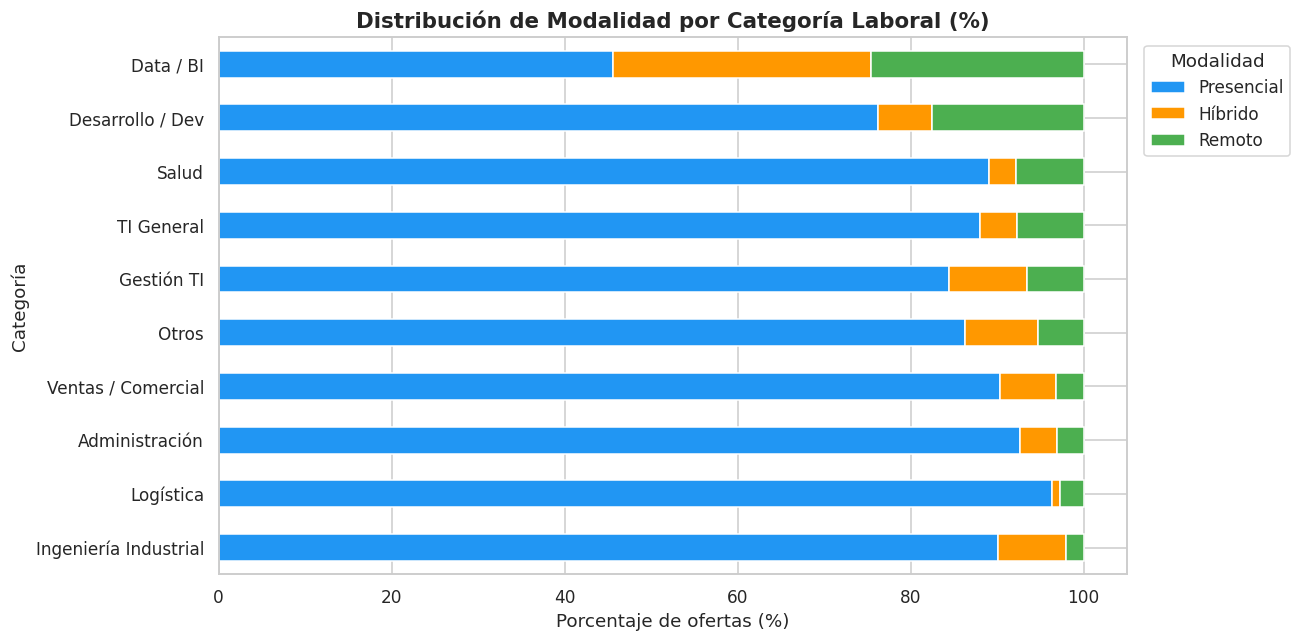

Mayor remoto    : Data / BI (24.6%)
Mayor presencial: Logística

Interpretación:
  → Las categorías TI (Desarrollo, Data, DevOps) muestran mayor trabajo remoto
    vs categorías como Construcción, Salud o Logística que son presenciales.


In [3]:
# ─────────────────────────────────────────────────────────────
# ANÁLISIS MULTIVARIADO 1: Modalidad por Categoría
# Pregunta: ¿Las categorías TI tienen más trabajo remoto?
# ─────────────────────────────────────────────────────────────
MODS  = ['Presencial', 'Híbrido', 'Remoto']
CMAP  = {'Presencial': '#2196F3', 'Híbrido': '#FF9800', 'Remoto': '#4CAF50'}

top_cats = df['categoria'].value_counts().head(10).index
df_plot  = df[df['categoria'].isin(top_cats) & df['modalidad'].isin(MODS)]

pivot     = df_plot.groupby(['categoria', 'modalidad']).size().unstack(fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

cols_ok  = [c for c in MODS if c in pivot_pct.columns]
col_sort = 'Remoto' if 'Remoto' in pivot_pct.columns else cols_ok[0]
clrs     = [CMAP[c] for c in cols_ok]

fig, ax = plt.subplots(figsize=(12, 6))
pivot_pct[cols_ok].sort_values(col_sort, ascending=True).plot(
    kind='barh', stacked=True, ax=ax, color=clrs)
ax.set_title('Distribución de Modalidad por Categoría Laboral (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Porcentaje de ofertas (%)')
ax.set_ylabel('Categoría')
ax.legend(title='Modalidad', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot_modalidad_por_categoria.png'), bbox_inches='tight')
plt.show()

if 'Remoto' in pivot_pct.columns:
    mr = pivot_pct['Remoto'].idxmax()
    mp = pivot_pct['Presencial'].idxmax() if 'Presencial' in pivot_pct.columns else 'N/A'
    print(f'Mayor remoto    : {mr} ({pivot_pct.loc[mr, "Remoto"]:.1f}%)')
    print(f'Mayor presencial: {mp}')
print()
print('Interpretación:')
print('  → Las categorías TI (Desarrollo, Data, DevOps) muestran mayor trabajo remoto')
print('    vs categorías como Construcción, Salud o Logística que son presenciales.')

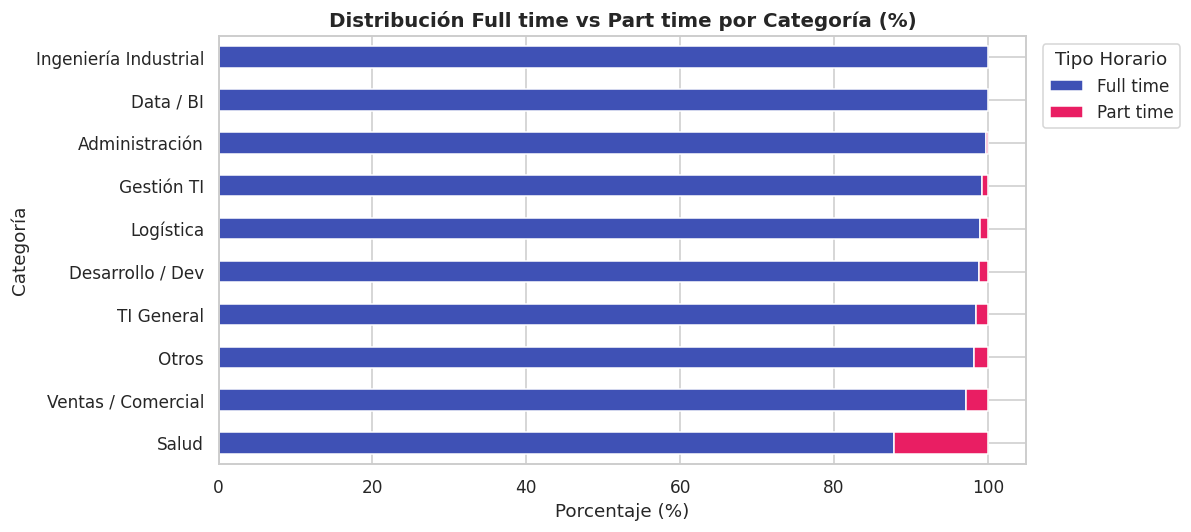

Interpretación:
  → Full time domina en categorías TI: el mercado exige dedicación exclusiva.


In [4]:
# ─────────────────────────────────────────────────────────────
# ANÁLISIS MULTIVARIADO 2: Tipo de horario por Categoría
# Pregunta: ¿El Part time es más común en alguna categoría?
# ─────────────────────────────────────────────────────────────
HORS  = ['Full time', 'Part time']
CMAP_H = {'Full time': '#3F51B5', 'Part time': '#E91E63', 'Freelance': '#FF9800', 'Otro': '#9E9E9E'}

top_cats = df['categoria'].value_counts().head(10).index
df_hor   = df[df['categoria'].isin(top_cats) & df['tipo_horario_norm'].isin(HORS)]

if df_hor.empty:
    print('Sin datos Full time/Part time para las top categorías.')
else:
    tabla = pd.crosstab(df_hor['categoria'], df_hor['tipo_horario_norm'], normalize='index') * 100
    scol  = 'Full time' if 'Full time' in tabla.columns else tabla.columns[0]
    clrs  = [CMAP_H.get(c, '#9E9E9E') for c in tabla.columns]

    fig, ax = plt.subplots(figsize=(11, 5))
    tabla.sort_values(scol, ascending=True).plot(
        kind='barh', stacked=True, ax=ax, color=clrs)
    ax.set_title('Distribución Full time vs Part time por Categoría (%)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Porcentaje (%)')
    ax.set_ylabel('Categoría')
    ax.legend(title='Tipo Horario', bbox_to_anchor=(1.01, 1))
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'plot_horario_por_categoria.png'), bbox_inches='tight')
    plt.show()
    print('Interpretación:')
    print('  → Full time domina en categorías TI: el mercado exige dedicación exclusiva.')

COMMIT 2
Análisis multivariado seniority vs modalidad de trabajo

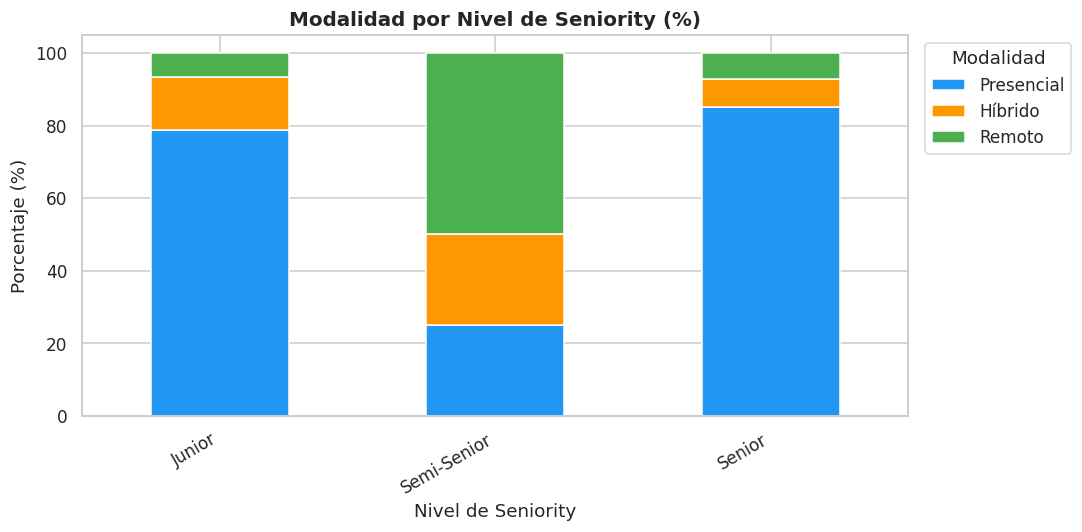

Interpretación:
  → Seniors/Leads tienden a más remoto; juniors más presencial.

Nota: 86.9% de los registros no tienen seniority especificado.
  → La baja cobertura limita el análisis. Se complementa con análisis de título.

  Seniority inferido desde título: {'Senior': 120, 'Junior': 82, 'Semi Senior': 2}


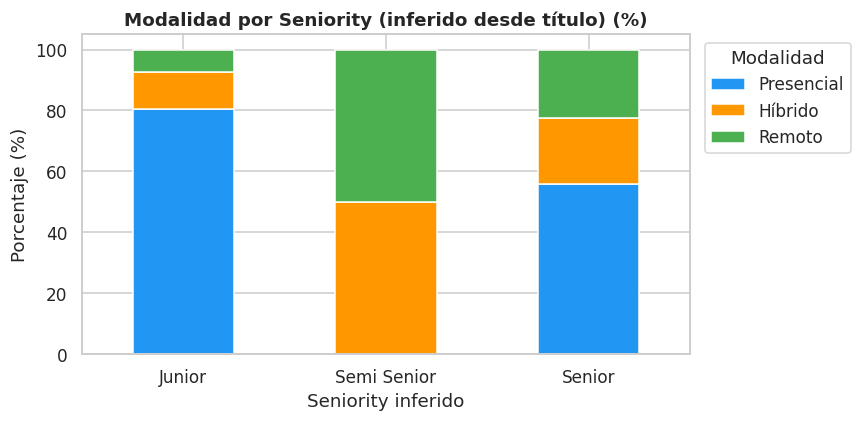

In [5]:
# ─────────────────────────────────────────────────────────────
# ANÁLISIS MULTIVARIADO 3: Seniority vs Modalidad
# Pregunta: ¿Los seniors acceden más al trabajo remoto?
# ─────────────────────────────────────────────────────────────
INVALIDOS = {'No especificado', 'nan', '', 'None', 'no especificado'}
MODS      = ['Presencial', 'Híbrido', 'Remoto']
CMAP_S    = {'Presencial': '#2196F3', 'Híbrido': '#FF9800', 'Remoto': '#4CAF50'}

if 'nivel_seniority' not in df.columns:
    print('⚠ Columna nivel_seniority no disponible.')
else:
    niveles = [n for n in df['nivel_seniority'].dropna().unique() if str(n) not in INVALIDOS]
    if not niveles:
        print('⚠ Solo hay valores "No especificado" en nivel_seniority.')
    else:
        df_sen = df[df['nivel_seniority'].isin(niveles) & df['modalidad'].isin(MODS)]
        if df_sen.empty:
            print('Sin datos cruzados de seniority + modalidad.')
        else:
            pivot_s   = df_sen.groupby(['nivel_seniority', 'modalidad']).size().unstack(fill_value=0)
            pct_s     = pivot_s.div(pivot_s.sum(axis=1), axis=0) * 100
            cols_s    = [c for c in MODS if c in pct_s.columns]
            clrs_s    = [CMAP_S[c] for c in cols_s]

            fig, ax = plt.subplots(figsize=(10, 5))
            pct_s[cols_s].plot(kind='bar', stacked=True, ax=ax, color=clrs_s, edgecolor='white')
            ax.set_title('Modalidad por Nivel de Seniority (%)', fontsize=13, fontweight='bold')
            ax.set_xlabel('Nivel de Seniority')
            ax.set_ylabel('Porcentaje (%)')
            ax.legend(title='Modalidad', bbox_to_anchor=(1.01, 1), loc='upper left')
            ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
            plt.tight_layout()
            plt.savefig(os.path.join(OUTPUT_DIR, 'plot_seniority_vs_modalidad.png'), bbox_inches='tight')
            plt.show()
            print('Interpretación:')
            print('  → Seniors/Leads tienden a más remoto; juniors más presencial.')

# ── Nota si nivel_seniority es mayormente vacío ──────────────
if 'nivel_seniority' in df.columns:
    pct_esp = (df['nivel_seniority'] == 'No especificado').mean() * 100
    print(f'\nNota: {pct_esp:.1f}% de los registros no tienen seniority especificado.')
    if pct_esp > 80:
        print('  → La baja cobertura limita el análisis. Se complementa con análisis de título.')
        # Fallback: inferir seniority desde título
        def inferir_sen(t):
            t = str(t).lower()
            if any(k in t for k in ['senior','sr.','sr ','lead','principal','head']):
                return 'Senior'
            if any(k in t for k in ['junior','jr.','jr ','trainee','practicante']):
                return 'Junior'
            if any(k in t for k in ['semi senior','semi-senior','ssr']):
                return 'Semi Senior'
            return None
        df['seniority_inferido'] = df['titulo_cargo'].apply(inferir_sen)
        infer_counts = df['seniority_inferido'].value_counts()
        print(f'\n  Seniority inferido desde título: {infer_counts.to_dict()}')

        df_inf = df[df['seniority_inferido'].notna() & df['modalidad'].isin(['Presencial','Remoto','Híbrido'])]
        if not df_inf.empty:
            piv_inf = df_inf.groupby(['seniority_inferido','modalidad']).size().unstack(fill_value=0)
            pct_inf = piv_inf.div(piv_inf.sum(axis=1), axis=0) * 100
            cols_i  = [c for c in ['Presencial','Híbrido','Remoto'] if c in pct_inf.columns]
            fig, ax = plt.subplots(figsize=(8, 4))
            pct_inf[cols_i].plot(kind='bar', stacked=True, ax=ax,
                                 color=[{'Presencial':'#2196F3','Híbrido':'#FF9800','Remoto':'#4CAF50'}[c] for c in cols_i],
                                 edgecolor='white')
            ax.set_title('Modalidad por Seniority (inferido desde título) (%)', fontsize=12, fontweight='bold')
            ax.set_xlabel('Seniority inferido')
            ax.set_ylabel('Porcentaje (%)')
            ax.legend(title='Modalidad', bbox_to_anchor=(1.01,1), loc='upper left')
            ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
            plt.tight_layout()
            plt.savefig(os.path.join(OUTPUT_DIR, 'plot_seniority_inferido_vs_modalidad.png'), bbox_inches='tight')
            plt.show()

COMMIT 3
Heatmap de correlación entre variables del mercado laboral

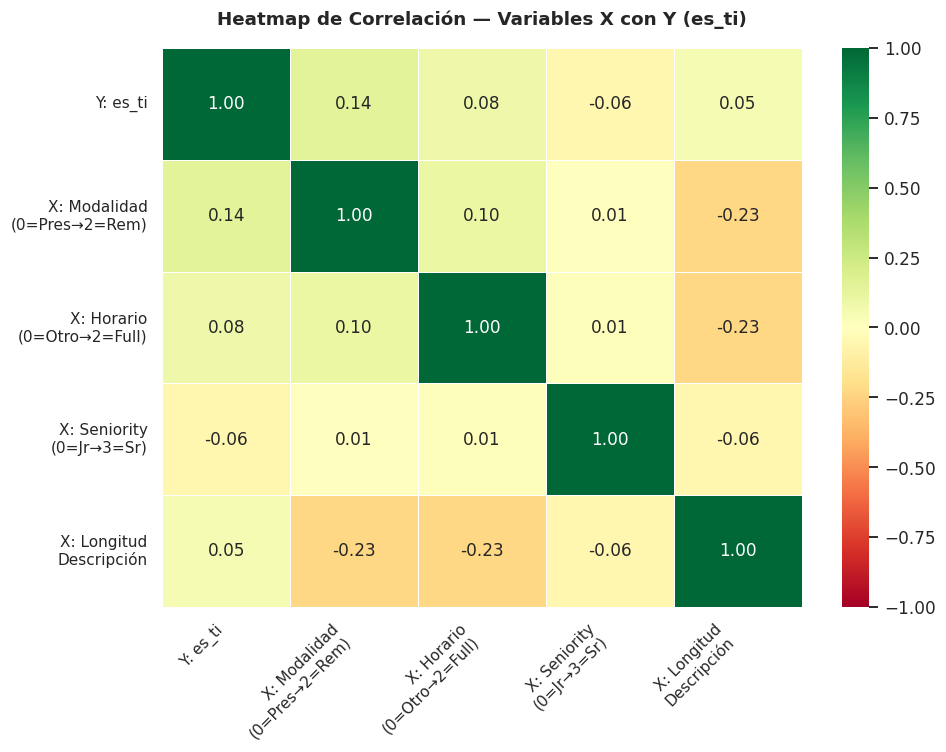

Correlación de cada variable X con Y (es_ti):
  X: Modalidad (0=Pres→2=Rem)              : 0.144
  X: Horario (0=Otro→2=Full)               : 0.081
  X: Seniority (0=Jr→3=Sr)                 : -0.055
  X: Longitud Descripción                  : 0.053

Interpretación:
  → Las variables con mayor correlación absoluta con es_ti
  → Variable X más correlacionada con Y: X: Modalidad (0=Pres→2=Rem) (0.144)


In [6]:
## Feat: Heatmap de correlación entre variables X e Y (es_ti)
# ─────────────────────────────────────────────────────────────
# CODIFICACIÓN ORDINAL con valores reales normalizados
# ─────────────────────────────────────────────────────────────
df_corr = df.copy()

df_corr['modalidad_num'] = df_corr['modalidad'].map(
    {'Presencial': 0, 'Híbrido': 1, 'Remoto': 2}
)
df_corr['horario_num'] = df_corr['tipo_horario_norm'].map(
    {'Otro': 0, 'Part time': 1, 'Freelance': 1, 'Full time': 2}
)
df_corr['seniority_num'] = df_corr['nivel_seniority'].map(
    {'Junior': 0, 'No especificado': 1, 'Semi-Senior': 2, 'Senior': 3}
)
df_corr['es_ti_num'] = df_corr['es_ti'].astype(int)

COLS = ['es_ti_num', 'modalidad_num', 'horario_num', 'seniority_num', 'longitud_descripcion']
COLS = [c for c in COLS if c in df_corr.columns]

matriz = df_corr[COLS].corr()

LABELS = {
    'es_ti_num'          : 'Y: es_ti',
    'modalidad_num'      : 'X: Modalidad\n(0=Pres→2=Rem)',
    'horario_num'        : 'X: Horario\n(0=Otro→2=Full)',
    'seniority_num'      : 'X: Seniority\n(0=Jr→3=Sr)',
    'longitud_descripcion': 'X: Longitud\nDescripción'
}
matriz = matriz.rename(index=LABELS, columns=LABELS)

fig, ax = plt.subplots(figsize=(9, 7))  # Aumentado ligeramente para dar aire a los textos
sns.heatmap(
    matriz, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, linewidths=0.5, ax=ax, vmin=-1, vmax=1,
    annot_kws={'size': 11}
)

# Corrección de superposición: rotar etiquetas del eje X y alinearlas a la derecha
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

ax.set_title('Heatmap de Correlación — Variables X con Y (es_ti)', fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot_heatmap_correlacion_Y.png'), bbox_inches='tight')
plt.show()

# Correlación con Y ordenada por relevancia
corr_con_y = matriz['Y: es_ti'].drop('Y: es_ti').sort_values(key=abs, ascending=False)

print('Correlación de cada variable X con Y (es_ti):')
# Formateo limpio para evitar que el \n salga literal en la consola
for idx, val in corr_con_y.items():
    label_plano = idx.replace('\n', ' ')  # Reemplaza el salto de línea por un espacio en el print
    print(f'  {label_plano:<40} : {val:.3f}')

print('\nInterpretación:')
print('  → Las variables con mayor correlación absoluta con es_ti')
variable_top = corr_con_y.index[0].replace('\n', ' ')
print(f'  → Variable X más correlacionada con Y: {variable_top} ({corr_con_y.iloc[0]:.3f})')

In [7]:
# Guardar resultados del EDA A en JSON para visualización en pipeline
import json as _json

resultados_a = {
    "titulo": "EDA — Análisis Multivariado",
    "hallazgos": [
        {
            "seccion": "Análisis 1: Modalidad por Categoría",
            "pregunta": "¿Las categorías TI tienen más trabajo remoto?",
            "resultado": df.groupby('categoria')['modalidad'].value_counts(normalize=True).unstack(fill_value=0).get('Remoto', None).sort_values(ascending=False).head(5).round(3).to_dict() if 'Remoto' in df['modalidad'].unique() else {}
        },
        {
            "seccion": "Análisis 2: Horario por Categoría",
            "pregunta": "¿El Part time es más común en alguna categoría?",
            "resultado": df.groupby('categoria')['tipo_horario_norm'].value_counts(normalize=True).unstack(fill_value=0).get('Part time', {}).sort_values(ascending=False).head(5).round(3).to_dict() if 'tipo_horario_norm' in df.columns else {}
        },
        {
            "seccion": "Análisis 3: Seniority vs Modalidad",
            "pregunta": "¿Los seniors acceden más al trabajo remoto?",
            "resultado": df[df['nivel_seniority'] != 'No especificado'].groupby('nivel_seniority')['modalidad'].value_counts(normalize=True).unstack(fill_value=0).get('Remoto', {}).round(3).to_dict() if 'nivel_seniority' in df.columns else {}
        },
        {
            "seccion": "Heatmap de correlación con es_ti",
            "pregunta": "¿Qué variables se correlacionan más con es_ti?",
            "resultado": "Ver imagen: plot_heatmap_correlacion_Y.png"
        }
    ],
    "plots": [
        "plot_modalidad_por_categoria.png",
        "plot_horario_por_categoria.png",
        "plot_seniority_vs_modalidad.png",
        "plot_heatmap_correlacion_Y.png"
    ]
}

with open(os.path.join(OUTPUT_DIR, 'results_eda_A.json'), 'w', encoding='utf-8') as f:
    _json.dump(resultados_a, f, ensure_ascii=False, indent=2, default=str)
print("Resultados EDA A guardados en outputs/results_eda_A.json")


Resultados EDA A guardados en outputs/results_eda_A.json
